In [2]:
%load_ext autoreload
%autoreload 2

import textwrap
from folde.util import load_checkpointed_model_eval, convert_compaign_result_collection_to_df
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load data for left panels (graphical abstract dataset)
results_abstract = load_checkpointed_model_eval(
    '../folde/model_evals',
    '250207-multimutant-benchmark',
    []
)
mutant_df_abstract, round_metrics_df_abstract = convert_compaign_result_collection_to_df(results_abstract)



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loading results for DMSs: {'GRB2_HUMAN_Faure_2021', 'PABP_YEAST_Melamed_2013', 'SPG1_STRSG_Olson_2014'}


In [3]:
import re
from collections import Counter


FAMILY_ORDER = ["random", "random forest", "zero-shot", "FolDE"]
FAMILY_PREFIXES = [
    ("RandomToRandomForest", "random forest", "RandomForest"),
    ("OnlyNaturalness", "zero-shot", "Naturalness"),
    ("FolDE", "FolDE", "FolDE"),
    ("Random", "random", "Random"),
]
BASE_COLORS = {
    "FolDE": "#E69F00",
    "zero-shot": "#CC79A7",
    "random forest": "#56B4E9",
    "random": "#999999",
}
COLOR_OVERRIDES = {
    "FolDE": "#E69F00",
    "FolDE E1": "#D55E00",
    "FolDE E1 MSA": "#009E73",
    "zero-shot": "#CC79A7",
    "zero-shot E1": "#0072B2",
    "zero-shot E1 MSA": "#56B4E9",
    "random": "#999999",
    "random forest": "#56B4E9",
}
CONFIG_LABEL_OVERRIDES = {
    # "FolDE-E1msaFolDE": "FolDE E1-MSA",
}


def _split_config_name(config_name: str) -> tuple[str, str]:
    for prefix, family_label, drop_suffix in FAMILY_PREFIXES:
        if config_name.startswith(prefix):
            suffix = config_name[len(prefix):].lstrip("-")
            if drop_suffix:
                suffix = re.sub(rf"{drop_suffix}$", "", suffix, flags=re.IGNORECASE).strip("-")
            return family_label, suffix
    parts = config_name.split("-", 1)
    family_label = parts[0]
    suffix = parts[1] if len(parts) > 1 else ""
    return family_label, suffix


def _format_suffix(suffix: str) -> str:
    suffix = suffix.strip()
    if not suffix or suffix.lower() == "base":
        return ""
    suffix = suffix.replace("_", "-")
    suffix = re.sub(r"(?i)e1msa", "E1-MSA", suffix)
    suffix = re.sub(r"(?i)e1", "E1", suffix)
    suffix = suffix.replace("-", " ")
    suffix = re.sub(r"\s+", " ", suffix).strip()
    return suffix


def _format_config_label(config_name: str) -> tuple[str, str]:
    family_label, suffix = _split_config_name(config_name)
    suffix_label = _format_suffix(suffix)
    if not suffix_label:
        return family_label, family_label
    return f"{family_label} {suffix_label}", family_label


def _config_sort_key(config_name: str) -> tuple[int, int, str, str]:
    family_label, suffix = _split_config_name(config_name)
    suffix_label = _format_suffix(suffix)
    family_rank = FAMILY_ORDER.index(family_label) if family_label in FAMILY_ORDER else len(FAMILY_ORDER)
    suffix_rank = 0 if not suffix_label else 1
    return (family_rank, suffix_rank, suffix_label.lower(), config_name)


def _build_palette(
    label_order: list[str],
    label_family_map: dict[str, str],
    color_overrides: dict[str, str] | None = None,
) -> dict[str, tuple[float, float, float] | str]:
    palette: dict[str, tuple[float, float, float] | str] = {}
    color_overrides = color_overrides or {}
    for label in label_order:
        if label in color_overrides:
            palette[label] = color_overrides[label]

    for family_label, base_color in BASE_COLORS.items():
        family_labels = [
            label
            for label in label_order
            if label_family_map.get(label) == family_label and label not in palette
        ]
        if not family_labels:
            continue
        family_colors = sns.light_palette(base_color, n_colors=len(family_labels), reverse=True)
        for label, color in zip(family_labels, family_colors):
            palette[label] = color

    unknown_labels = [label for label in label_order if label not in palette]
    if unknown_labels:
        extra_colors = sns.color_palette("colorblind", n_colors=len(unknown_labels))
        for label, color in zip(unknown_labels, extra_colors):
            palette[label] = color

    return palette


def build_config_display_maps(
    config_names: list[str],
    label_overrides: dict[str, str] | None = None,
    color_overrides: dict[str, str] | None = None,
) -> tuple[dict[str, str], list[str], dict[str, tuple[float, float, float] | str]]:
    ordered_names = sorted(config_names, key=_config_sort_key)
    label_map: dict[str, str] = {}

    for name in ordered_names:
        label, _ = _format_config_label(name)
        label_map[name] = label

    label_counts = Counter(label_map.values())
    if any(count > 1 for count in label_counts.values()):
        for name, label in list(label_map.items()):
            if label_counts[label] > 1 and (not label_overrides or name not in label_overrides):
                label_map[name] = f"{label} ({name})"

    if label_overrides:
        missing = [name for name in label_overrides if name not in label_map]
        if missing:
            print(f"Overrides ignored for missing configs: {missing}")
        for name, label in label_overrides.items():
            if name in label_map:
                label_map[name] = label

    label_order: list[str] = []
    label_family_map: dict[str, str] = {}
    for name in ordered_names:
        label = label_map.get(name, name)
        if label not in label_family_map:
            family_label, _ = _split_config_name(name)
            label_family_map[label] = family_label
        if label not in label_order:
            label_order.append(label)

    palette = _build_palette(label_order, label_family_map, color_overrides)
    return label_map, label_order, palette


def _labels_for_configs(
    config_names: list[str],
    label_map: dict[str, str],
    label_order: list[str],
) -> list[str]:
    labels = {label_map.get(name, name) for name in config_names}
    return [label for label in label_order if label in labels]


CONFIG_NAMES = round_metrics_df_abstract.config_name.unique().tolist()
CONFIG_LABEL_MAP, CONFIG_LABEL_ORDER, COLOR_MAP = build_config_display_maps(
    CONFIG_NAMES,
    label_overrides=CONFIG_LABEL_OVERRIDES,
    color_overrides=COLOR_OVERRIDES,
)

BASE_CONFIGS = [c for c in CONFIG_NAMES if 'e1' not in c.lower()]
E1_CONFIGS = [c for c in CONFIG_NAMES if 'e1' in c.lower()]

BASE_LABEL_ORDER = _labels_for_configs(BASE_CONFIGS, CONFIG_LABEL_MAP, CONFIG_LABEL_ORDER)
E1_LABEL_ORDER = _labels_for_configs(E1_CONFIGS, CONFIG_LABEL_MAP, CONFIG_LABEL_ORDER)


In [4]:
# Review the auto-generated display names.
# Edit CONFIG_LABEL_OVERRIDES in the previous cell if you want to rename anything.
config_display_df = pd.DataFrame({
    "config_name": CONFIG_NAMES,
    "display_name": [CONFIG_LABEL_MAP.get(name, name) for name in CONFIG_NAMES],
})
config_display_df["is_e1"] = config_display_df["config_name"].str.contains("e1", case=False, na=False)
config_display_df = config_display_df.sort_values(
    ["is_e1", "display_name", "config_name"]
).reset_index(drop=True)
config_display_df


,config_name,display_name,is_e1
0,FolDE-base,FolDE,False
1,Random,random,False
2,OnlyNaturalness,zero-shot,False
3,FolDE-E1FolDE,FolDE E1,True
4,FolDE-E1msaFolDE,FolDE E1 MSA,True
5,FolDE-E1zsEsmPre,FolDE E1zsEsmPre,True
6,FolDE-ESMzsE1Pre,FolDE ESMzsE1Pre,True
7,OnlyNaturalness-E1Naturalness,zero-shot E1,True
8,OnlyNaturalness-E1msaNaturalness,zero-shot E1 MSA,True


In [5]:
# Build a per-config mapping table for inspection or manual overrides.
config_name_map = {
    name: {
        'display_name': CONFIG_LABEL_MAP.get(name, name),
        'family': _split_config_name(name)[0],
        'suffix': _split_config_name(name)[1],
        'is_e1': bool(re.search('e1', name, flags=re.IGNORECASE)),
    }
    for name in CONFIG_NAMES
}
config_name_map_df = (
    pd.DataFrame.from_dict(config_name_map, orient='index')
    .reset_index()
    .rename(columns={'index': 'config_name'})
    .sort_values(['is_e1', 'family', 'display_name', 'config_name'])
    .reset_index(drop=True)
)
config_name_map_df


,config_name,display_name,family,suffix,is_e1
0,FolDE-base,FolDE,FolDE,base,False
1,Random,random,random,,False
2,OnlyNaturalness,zero-shot,zero-shot,,False
3,FolDE-E1FolDE,FolDE E1,FolDE,E1,True
4,FolDE-E1msaFolDE,FolDE E1 MSA,FolDE,E1msa,True
5,FolDE-E1zsEsmPre,FolDE E1zsEsmPre,FolDE,E1zsEsmPre,True
6,FolDE-ESMzsE1Pre,FolDE ESMzsE1Pre,FolDE,ESMzsE1Pre,True
7,OnlyNaturalness-E1Naturalness,zero-shot E1,zero-shot,E1,True
8,OnlyNaturalness-E1msaNaturalness,zero-shot E1 MSA,zero-shot,E1msa,True


Base stats for round 3:
             cumulative_10pct_hits  has_found_top_1pct  best_percentile_so_far
config_name                                                                   
FolDE                    28.600000            1.000000                0.997655
random                    5.233333            0.366667                0.982169
zero-shot                26.066667            0.900000                0.995361
E1 stats for round 3:
                  cumulative_10pct_hits  has_found_top_1pct  \
config_name                                                   
FolDE E1                      32.933333            1.000000   
FolDE E1 MSA                  30.133333            0.966667   
FolDE E1zsEsmPre              28.866667            0.933333   
FolDE ESMzsE1Pre              29.566667            0.933333   
zero-shot E1                  29.166667            0.866667   
zero-shot E1 MSA              24.000000            0.666667   

                  best_percentile_so_far  
config_name

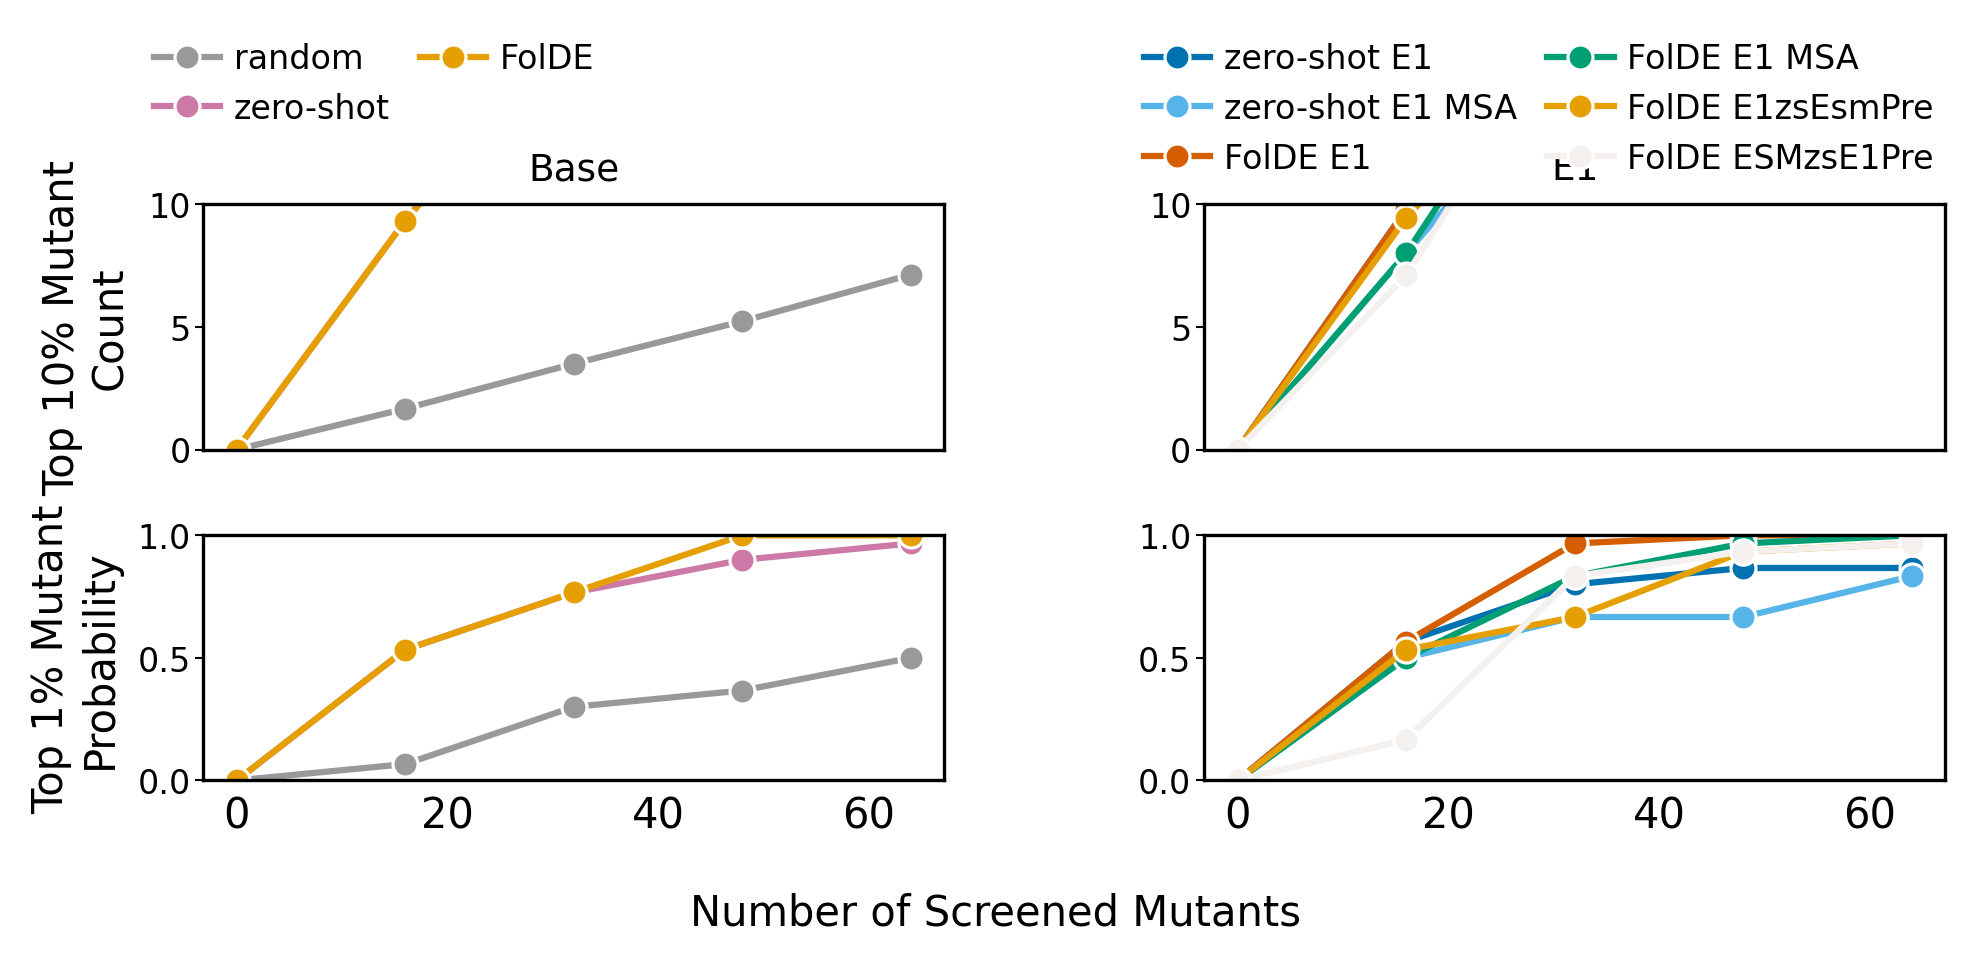

In [6]:
def _build_plot_df(
    label_order: list[str],
    config_label_map: dict[str, str],
    last_round_num: int,
) -> pd.DataFrame:
    plot_df = round_metrics_df_abstract.copy()
    plot_df['Screened mutants'] = plot_df.round_num * 16
    plot_df['config_name'] = plot_df.config_name.map(config_label_map)
    plot_df['config_name'] = plot_df['config_name'].fillna(plot_df.config_name)
    plot_df = plot_df[
        (plot_df.round_num <= last_round_num)
        & (plot_df.config_name.isin(label_order))
    ]
    plot_df = pd.concat([plot_df, pd.DataFrame([{
        'config_name': config_name,
        'Screened mutants': 0,
        'round_num': 0,
        'cumulative_10pct_hits': 0,
        'has_found_top_1pct': 0,
    } for config_name in label_order])]).reset_index()
    return plot_df


def _plot_metric(ax, plot_df, metric, label_order, palette):
    sns.lineplot(
        ax=ax,
        data=plot_df,
        y=metric,
        x='Screened mutants',
        hue='config_name',
        errorbar=None,
        marker='o',
        hue_order=label_order,
        palette=palette,
    )


def _wrap_axis_label(label: str, width: int = 18) -> str:
    normalized_label = label.replace("\\n", "\n")
    lines = normalized_label.splitlines() or [normalized_label]
    wrapped_lines = [
        textwrap.fill(
            line,
            width=width,
            break_long_words=False,
            break_on_hyphens=False,
        )
        for line in lines
    ]
    return "\n".join(wrapped_lines)


def plot_four_panel_figure(
    _METRIC_TOP, _TOP_METRIC_LABEL,
    _METRIC_BOTTOM, _BOTTOM_METRIC_LABEL,
    _LAST_ROUND_NUM,
    config_label_map,
    base_label_order,
    e1_label_order,
    color_map,
    round_stats=3,
    left_title='Base',
    right_title='E1',
    left_stats_label='Base',
    right_stats_label='E1',
):
    fig, ((ax_tl, ax_tr), (ax_bl, ax_br)) = plt.subplots(
        2,
        2,
        figsize=(6.6, 3.2),
        dpi=300,
        sharex='col',
    )

    base_plot_df = _build_plot_df(base_label_order, config_label_map, _LAST_ROUND_NUM)
    e1_plot_df = _build_plot_df(e1_label_order, config_label_map, _LAST_ROUND_NUM)

    if base_label_order:
        _plot_metric(ax_tl, base_plot_df, _METRIC_TOP, base_label_order, color_map)
        _plot_metric(ax_bl, base_plot_df, _METRIC_BOTTOM, base_label_order, color_map)
    else:
        ax_tl.axis('off')
        ax_bl.axis('off')

    if e1_label_order:
        _plot_metric(ax_tr, e1_plot_df, _METRIC_TOP, e1_label_order, color_map)
        _plot_metric(ax_br, e1_plot_df, _METRIC_BOTTOM, e1_label_order, color_map)
    else:
        ax_tr.axis('off')
        ax_br.axis('off')

    ax_tl.set_ylabel(_wrap_axis_label(_TOP_METRIC_LABEL))
    ax_tl.set_xlabel('')
    ax_tr.set_ylabel('')
    ax_tr.set_xlabel('')
    ax_bl.set_ylabel(_wrap_axis_label(_BOTTOM_METRIC_LABEL))
    ax_bl.set_xlabel('')
    ax_br.set_ylabel('')
    ax_br.set_xlabel('')

    if base_label_order:
        ax_tl.set_title(left_title, fontsize=9, pad=6)
    if e1_label_order:
        ax_tr.set_title(right_title, fontsize=9, pad=6)

    base_handles = []
    if base_label_order:
        handles, labels = ax_tl.get_legend_handles_labels()
        handle_map = {label: handle for label, handle in zip(labels, handles)}
        base_handles = [handle_map[label] for label in base_label_order if label in handle_map]
        legend = ax_tl.get_legend()
        if legend is not None:
            legend.remove()

    e1_handles = []
    if e1_label_order:
        handles, labels = ax_tr.get_legend_handles_labels()
        handle_map = {label: handle for label, handle in zip(labels, handles)}
        e1_handles = [handle_map[label] for label in e1_label_order if label in handle_map]
        legend = ax_tr.get_legend()
        if legend is not None:
            legend.remove()

    for ax in (ax_bl, ax_br):
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

    if base_label_order and base_handles:
        fig.legend(
            base_handles,
            base_label_order,
            loc='upper left',
            bbox_to_anchor=(0.06, 0.98),
            bbox_transform=fig.transFigure,
            fontsize=8,
            ncol=min(2, max(1, len(base_label_order))),
            columnspacing=0.9,
            handletextpad=0.4,
            frameon=False,
        )

    if e1_label_order and e1_handles:
        fig.legend(
            e1_handles,
            e1_label_order,
            loc='upper left',
            bbox_to_anchor=(0.56, 0.98),
            bbox_transform=fig.transFigure,
            fontsize=8,
            ncol=min(2, max(1, len(e1_label_order))),
            columnspacing=0.9,
            handletextpad=0.4,
            frameon=False,
        )

    fig.supxlabel('Number of Screened Mutants', fontsize=10, y=0.02)
    fig.subplots_adjust(left=0.1, right=0.98, top=0.78, bottom=0.18, wspace=0.35, hspace=0.35)

    for ax in (ax_tl, ax_tr, ax_bl, ax_br):
        ax.tick_params(axis='y', labelsize=8, pad=1, length=2, width=0.5)
        ax.tick_params(axis='x', length=0)

    if base_label_order:
        base_stats = base_plot_df[base_plot_df.round_num == round_stats].groupby(
            ['config_name']
        ).agg({
            'cumulative_10pct_hits': 'mean',
            'has_found_top_1pct': 'mean',
            'best_percentile_so_far': 'mean'
        })
        print(f'{left_stats_label} stats for round {round_stats}:')
        print(base_stats)

    if e1_label_order:
        e1_stats = e1_plot_df[e1_plot_df.round_num == round_stats].groupby(
            ['config_name']
        ).agg({
            'cumulative_10pct_hits': 'mean',
            'has_found_top_1pct': 'mean',
            "best_percentile_so_far": 'mean'
        })
        print(f'{right_stats_label} stats for round {round_stats}:')
        print(e1_stats)

    if _METRIC_TOP == 'frac_10pct_hits':
        for ax in (ax_tl, ax_tr):
            ax.set_ylim(0, 0.3)
    elif _METRIC_TOP == 'new_10pct_hits' or _METRIC_TOP == 'cumulative_10pct_hits':
        for ax in (ax_tl, ax_tr):
            ax.set_ylim(0, 10)
            ax.set_yticks([0, 5, 10])

    for ax in (ax_bl, ax_br):
        ax.set_ylim(0, 1)
    return fig, (ax_tl, ax_tr, ax_bl, ax_br)


# METRIC_TOP, TOP_METRIC_LABEL = 'held_out_batch_10pct', 'Frac of Mutants in\nTop 10% Hits (held out)'
# METRIC_TOP, TOP_METRIC_LABEL = 'cumulative_10pct_hits', 'Cumulative\nTop 10% Mutants'
METRIC_TOP, TOP_METRIC_LABEL = 'cumulative_10pct_hits', 'Top 10% Mutant\nCount'
# METRIC_TOP, TOP_METRIC_LABEL = 'new_10pct_hits', 'Number of\nNew Top 10% Hits'
# METRIC_TOP, TOP_METRIC_LABEL = 'frac_10pct_hits', 'Fraction in\nTop 10%'

METRIC_BOTTOM, BOTTOM_METRIC_LABEL = 'has_found_top_1pct', 'Top 1% Mutant\nProbability'
# METRIC_BOTTOM, BOTTOM_METRIC_LABEL = 'held_out_activity_spearman', 'Spearman'
# METRIC_BOTTOM, BOTTOM_METRIC_LABEL = 'held_out_1pct_recall', 'Top 10% Recall'

LAST_ROUND_NUM = 4

fig, (ax_tl, ax_tr, ax_bl, ax_br) = plot_four_panel_figure(
    METRIC_TOP, TOP_METRIC_LABEL,
    METRIC_BOTTOM, BOTTOM_METRIC_LABEL,
    LAST_ROUND_NUM,
    CONFIG_LABEL_MAP,
    BASE_LABEL_ORDER,
    E1_LABEL_ORDER,
    COLOR_MAP,
    round_stats=3,
)

plt.savefig('notebooks/isaac/fig1_combined.svg', dpi=300, format='svg', bbox_inches='tight')


Zero-shot stats for round 4:
                  cumulative_10pct_hits  has_found_top_1pct  \
config_name                                                   
zero-shot                     34.233333            0.966667   
zero-shot E1                  38.800000            0.866667   
zero-shot E1 MSA              31.566667            0.833333   

                  best_percentile_so_far  
config_name                               
zero-shot                       0.996967  
zero-shot E1                    0.996599  
zero-shot E1 MSA                0.994910  
FolDE stats for round 4:
                  cumulative_10pct_hits  has_found_top_1pct  \
config_name                                                   
FolDE                         40.333333            1.000000   
FolDE E1                      45.666667            1.000000   
FolDE E1 MSA                  42.033333            1.000000   
FolDE E1zsEsmPre              40.700000            0.966667   
FolDE ESMzsE1Pre              41.4666

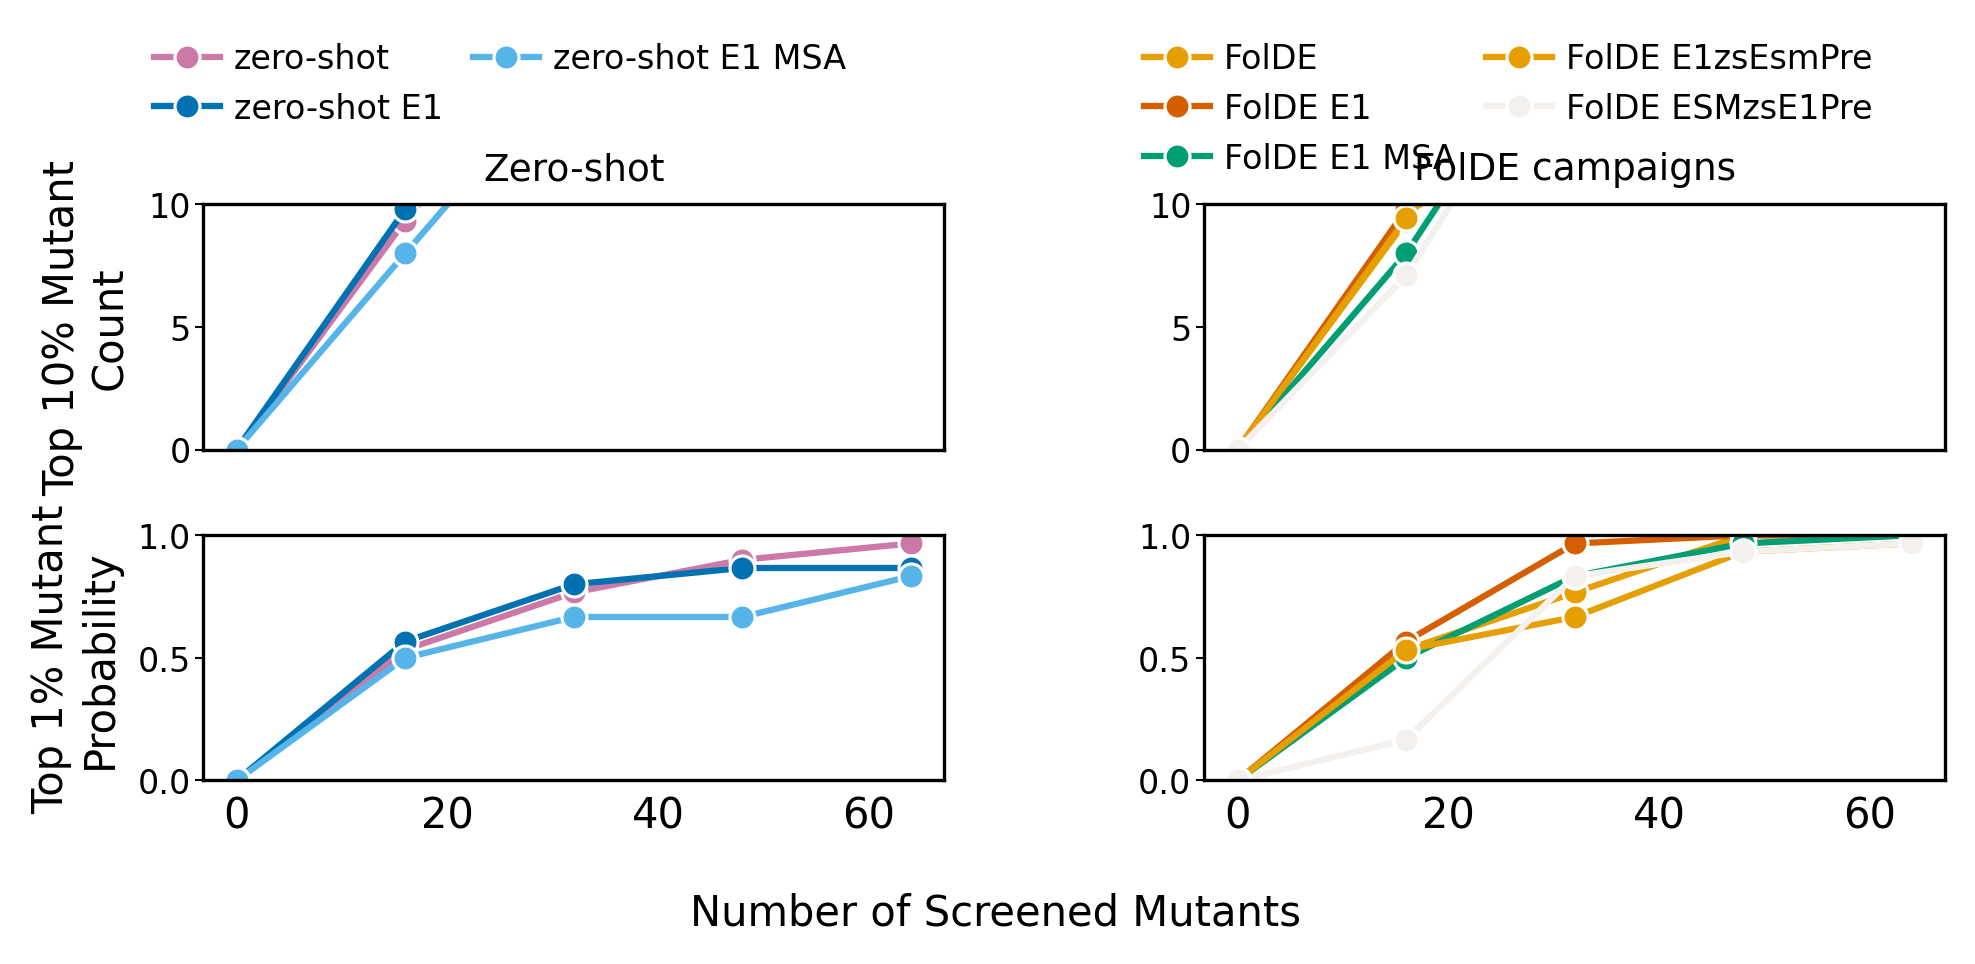

In [7]:
ZERO_SHOT_CONFIGS = [c for c in CONFIG_NAMES if _split_config_name(c)[0] == 'zero-shot']
FOLDE_CONFIGS = [c for c in CONFIG_NAMES if _split_config_name(c)[0] == 'FolDE']

ZERO_SHOT_LABEL_ORDER = _labels_for_configs(ZERO_SHOT_CONFIGS, CONFIG_LABEL_MAP, CONFIG_LABEL_ORDER)
FOLDE_LABEL_ORDER = _labels_for_configs(FOLDE_CONFIGS, CONFIG_LABEL_MAP, CONFIG_LABEL_ORDER)

fig, (ax_tl, ax_tr, ax_bl, ax_br) = plot_four_panel_figure(
    METRIC_TOP, TOP_METRIC_LABEL,
    METRIC_BOTTOM, BOTTOM_METRIC_LABEL,
    LAST_ROUND_NUM,
    CONFIG_LABEL_MAP,
    ZERO_SHOT_LABEL_ORDER,
    FOLDE_LABEL_ORDER,
    COLOR_MAP,
    round_stats=4,
    left_title='Zero-shot',
    right_title='FolDE campaigns',
    left_stats_label='Zero-shot',
    right_stats_label='FolDE',
)

plt.savefig('notebooks/isaac/fig1_zeroshot_vs_folde.svg', dpi=120, format='svg', bbox_inches='tight')


In [8]:
%matplotlib widget

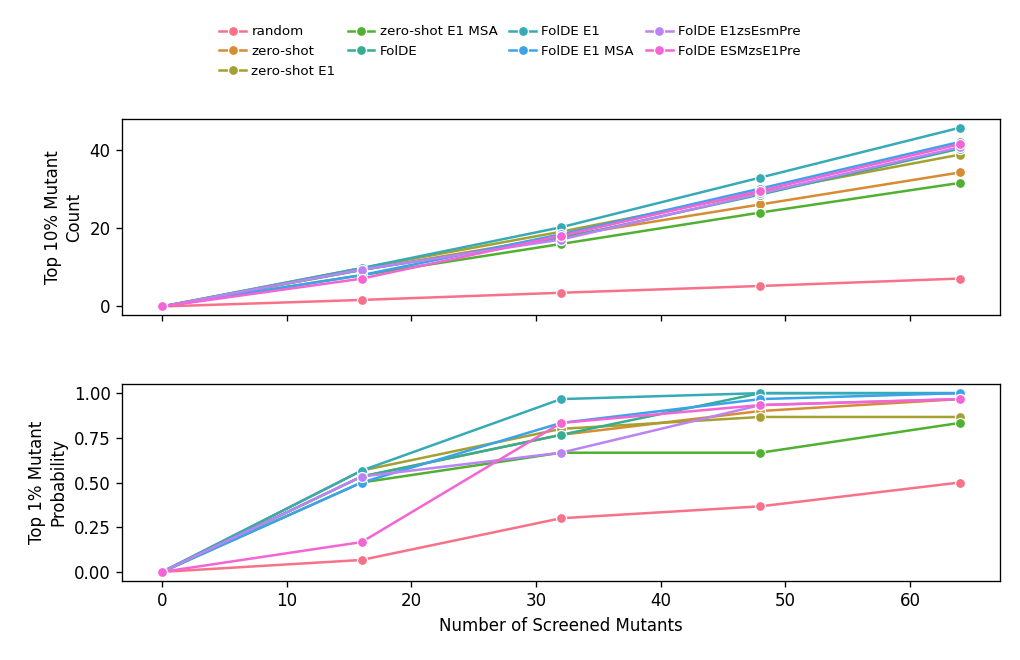

In [9]:
# Plot all configs together (no family splits).
ALL_LABEL_ORDER = CONFIG_LABEL_ORDER
all_plot_df = _build_plot_df(ALL_LABEL_ORDER, CONFIG_LABEL_MAP, LAST_ROUND_NUM)

all_palette = dict(zip(ALL_LABEL_ORDER, sns.color_palette('husl', n_colors=len(ALL_LABEL_ORDER))))

# Enable an interactive backend if available so legend clicks register.
def _enable_interactive_backend() -> bool:
    ip = get_ipython()
    if ip is None:
        return False
    try:
        import ipympl  # noqa: F401
    except Exception:
        try:
            ip.run_line_magic('matplotlib', 'notebook')
            return True
        except Exception:
            print('Interactive backend not available. Install ipympl (pip install ipympl).')
            return False
    try:
        ip.run_line_magic('matplotlib', 'widget')
        return True
    except Exception:
        try:
            ip.run_line_magic('matplotlib', 'notebook')
            return True
        except Exception:
            print('Interactive backend not available. Install ipympl (pip install ipympl).')
            return False

INTERACTIVE_BACKEND_ENABLED = _enable_interactive_backend()
DISPLAY_DPI = 120 if INTERACTIVE_BACKEND_ENABLED else 300

fig, (ax_top, ax_bottom) = plt.subplots(
    2,
    1,
    figsize=(8.5, 5.5),
    dpi=DISPLAY_DPI,
    sharex=True,
)

_plot_metric(ax_top, all_plot_df, METRIC_TOP, ALL_LABEL_ORDER, all_palette)
_plot_metric(ax_bottom, all_plot_df, METRIC_BOTTOM, ALL_LABEL_ORDER, all_palette)

ax_top.set_ylabel(_wrap_axis_label(TOP_METRIC_LABEL))
ax_top.set_xlabel('')
ax_bottom.set_ylabel(_wrap_axis_label(BOTTOM_METRIC_LABEL))
ax_bottom.set_xlabel('Number of Screened Mutants')

handles, labels = ax_top.get_legend_handles_labels()
handle_map = {label: handle for label, handle in zip(labels, handles)}
ordered_handles = [handle_map[label] for label in ALL_LABEL_ORDER if label in handle_map]

legend = ax_top.get_legend()
if legend is not None:
    legend.remove()
legend = ax_bottom.get_legend()
if legend is not None:
    legend.remove()

legend = None
if ordered_handles:
    legend = fig.legend(
        ordered_handles,
        ALL_LABEL_ORDER,
        loc='upper center',
        bbox_to_anchor=(0.5, 0.98),
        bbox_transform=fig.transFigure,
        fontsize=8,
        ncol=min(4, max(1, len(ALL_LABEL_ORDER))),
        columnspacing=0.9,
        handletextpad=0.4,
        frameon=False,
    )

if legend is not None:
    # Click legend entries to toggle config visibility.
    from matplotlib import colors as mcolors

    def _rgba_key(color):
        return tuple(round(c, 6) for c in mcolors.to_rgba(color))

    label_to_color = {label: _rgba_key(color) for label, color in all_palette.items()}
    color_to_labels = {}
    for label, color in label_to_color.items():
        color_to_labels.setdefault(color, []).append(label)

    label_to_lines = {label: [] for label in ALL_LABEL_ORDER}
    for ax in (ax_top, ax_bottom):
        for line in ax.get_lines():
            label = line.get_label()
            if label in label_to_lines and line not in label_to_lines[label]:
                label_to_lines[label].append(line)
                continue
            color_key = _rgba_key(line.get_color())
            for label in color_to_labels.get(color_key, []):
                if line not in label_to_lines[label]:
                    label_to_lines[label].append(line)

    label_to_legend = {}
    for legline, legtext in zip(legend.get_lines(), legend.get_texts()):
        label = legtext.get_text()
        if label in label_to_lines:
            legline.set_picker(True)
            legline.set_pickradius(6)
            legtext.set_picker(True)
            label_to_legend[label] = (legline, legtext)

    artist_to_label = {}
    for label, (legline, legtext) in label_to_legend.items():
        artist_to_label[legline] = label
        artist_to_label[legtext] = label

    def _set_legend_alpha(label, visible):
        legline, legtext = label_to_legend[label]
        alpha = 1.0 if visible else 0.2
        legline.set_alpha(alpha)
        legtext.set_alpha(alpha)

    def _toggle_config_visibility(event):
        label = artist_to_label.get(event.artist)
        if label is None:
            return
        lines = label_to_lines.get(label, [])
        if not lines:
            return
        new_visible = not lines[0].get_visible()
        for line in lines:
            line.set_visible(new_visible)
        _set_legend_alpha(label, new_visible)
        fig.canvas.draw_idle()

    fig.canvas.mpl_connect('pick_event', _toggle_config_visibility)

if not INTERACTIVE_BACKEND_ENABLED:
    print('Legend toggles need an interactive backend; rerun after enabling one.')

fig.subplots_adjust(left=0.12, right=0.98, top=0.82, bottom=0.12, hspace=0.35)
plt.savefig('notebooks/isaac/fig1_all_configs.svg', dpi=300, format='svg', bbox_inches='tight')
